<a href="https://colab.research.google.com/github/ElisavettaDudina/laba-1/blob/master/DudunaElisaveta_Laba1_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:

import pandas as pd
pd.set_option('display.width', 1000)  # Увеличить ширину
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)  # Запретить перенос
import numpy as np
from datetime import datetime, timedelta

# Настройка отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)




# Создание датасета

data = {
    'Клиент': ['Анна', 'Екатерина', 'Мария', 'Анна', 'Дарья', 'Елена', 'Екатерина', 'Ольга',
               'Светлана', 'Наталья'],
    'Услуга': ['Стрижка', 'Окрашивание', 'Маникюр', 'Стрижка', 'Педикюр', 'Укладка',
               'Окрашивание', None, 'Стрижка', 'Маникюр'],
    'Мастер': ['Елена', 'Александра', 'Ирина', 'Елена', 'Ирина', 'Александра',
               'Александра', None, 'Елена', 'Ирина'],
    'Цена': [1500, 3500, 2000, 1500, 2500, 1200, 3500, None, 1500, 2000],
    'Длительность_мин': [60, 120, 45, 60, 60, 40, None, None, 60, None],
    'Возраст_клиента': [25, 35, 28, 25, 42, 31, 35, 27, 52, 33]
}

df = pd.DataFrame(data)
print("Исходный DataFrame:")
print(df.to_string())


# Базовые методы
print("Базовые методы Pandas")

print("\nhead() - первые 5 строк:")
print(df.head())

print("\ntail() - последние 5 строк:")
print(df.tail())

print("\ninfo() - информация о датафрейме:")
df.info()

print("\ndescribe() - статистическое описание:")
print(df.describe())

print(f"\nshape - размерность: {df.shape}")

# Пустые значения
print("\nПустые значения")

# Количество пустых значений
null_counts = df.isnull().sum()
print("\na. Количество пустых значений по колонкам:")
print(null_counts[null_counts > 0])

# Процент пустых значений
null_percentage = (df.isnull().sum() / len(df) * 100)
print("\nb. Процент пустых значений по колонкам:")
print(null_percentage[null_percentage > 0])

# Замена пропущенных значений
print("\nc. Восстановление пропущенных значений:")

# Создаем копию для заполнения
df_filled = df.copy()

# Заполняем пропуски
df_filled['Услуга'] = df_filled['Услуга'].fillna('Стрижка')  # Самая популярная услуга
df_filled['Мастер'] = df_filled['Мастер'].fillna('Елена')    # Самый популярный мастер
df_filled['Цена'] = df_filled['Цена'].fillna(df_filled['Цена'].mean())  # Средняя цена
df_filled['Длительность_мин'] = df_filled['Длительность_мин'].fillna(df_filled['Длительность_мин'].mean())  # Средняя длительность

print("  - Пропуски в 'Услуга' заполнены значением 'Стрижка'")
print("  - Пропуски в 'Мастер' заполнены значением 'Елена'")
print("  - Пропуски в 'Цена' заполнены средним значением")
print("  - Пропуски в 'Длительность_мин' заполнены средним значением")

print(f"\nПосле заполнения осталось пропусков: {df_filled.isnull().sum().sum()}")

# Дубликаты

print("Удаление дубликатов")


initial_rows = len(df_filled)
duplicates_count = df_filled.duplicated().sum()

df_clean = df_filled.drop_duplicates().copy()
final_rows = len(df_clean)

print(f"Количество строк до удаления: {initial_rows}")
print(f"Количество найденных дубликатов: {duplicates_count}")
print(f"Количество строк после удаления: {final_rows}")

if duplicates_count > 0:
    print("\nНайденные дубликаты:")
    print(df_filled[df_filled.duplicated(keep=False)].sort_values(['Клиент', 'Услуга']))

# Индексация

# loc - выборка по меткам
print("\nloc - услуги мастера Елены:")
result_loc = df_clean.loc[df_clean['Мастер'] == 'Елена', ['Клиент', 'Услуга', 'Цена']]
print(result_loc)

# iloc - выборка по позициям
print("\niloc - первые 3 строки (только клиент и услуга):")
result_iloc = df_clean.iloc[:3, [0, 1, 3]]  # колонки: Клиент, Услуга, Цена
print(result_iloc)

# query - запросы
print("\nquery - дорогие услуги (цена > 2500):")
result_query = df_clean.query('Цена > 2500')[['Клиент', 'Услуга', 'Цена', 'Мастер']]
print(result_query)

# Работа с датами
print("\nРабота с датами")

# Создаем столбец с датами посещения
current_date = datetime.now()

# Генерируем даты посещений (от 1 до 30 дней назад)
np.random.seed(42)
visit_dates = []
for i in range(len(df_clean)):
    days_ago = np.random.randint(1, 30)
    visit_date = current_date - timedelta(days=days_ago)
    visit_dates.append(visit_date)

df_clean['Дата_посещения'] = visit_dates

print("Датафрейм с добавленной колонкой дат:")
print(df_clean[['Клиент', 'Услуга', 'Дата_посещения']].to_string())

# Рассчитываем количество дней до сегодня
df_clean['Дней_с_посещения'] = (current_date - df_clean['Дата_посещения']).dt.days

# Разделяем дату на компоненты
df_clean['Год'] = df_clean['Дата_посещения'].dt.year
df_clean['Месяц'] = df_clean['Дата_посещения'].dt.month
df_clean['День'] = df_clean['Дата_посещения'].dt.day


print("\nПосле разделения даты на компоненты:")
print(df_clean[['Клиент', 'Дата_посещения', 'Дней_с_посещения', 'Год', 'Месяц', 'День']].to_string())




Исходный DataFrame:
      Клиент       Услуга      Мастер    Цена  Длительность_мин  Возраст_клиента
0       Анна      Стрижка       Елена  1500.0              60.0               25
1  Екатерина  Окрашивание  Александра  3500.0             120.0               35
2      Мария      Маникюр       Ирина  2000.0              45.0               28
3       Анна      Стрижка       Елена  1500.0              60.0               25
4      Дарья      Педикюр       Ирина  2500.0              60.0               42
5      Елена      Укладка  Александра  1200.0              40.0               31
6  Екатерина  Окрашивание  Александра  3500.0               NaN               35
7      Ольга         None        None     NaN               NaN               27
8   Светлана      Стрижка       Елена  1500.0              60.0               52
9    Наталья      Маникюр       Ирина  2000.0               NaN               33
Базовые методы Pandas

head() - первые 5 строк:
      Клиент       Услуга      Мастер    

Загружено строк: 371528
Первые 5 строк:
           dateCrawled                            name  seller offerType  price abtest vehicleType  yearOfRegistration    gearbox  powerPS  model  kilometer  monthOfRegistration fuelType       brand notRepairedDamage          dateCreated  nrOfPictures  postalCode             lastSeen
0  2016-03-24 11:52:17                      Golf_3_1.6  privat   Angebot    480   test         NaN                1993    manuell        0   golf     150000                    0   benzin  volkswagen               NaN  2016-03-24 00:00:00             0       70435  2016-04-07 03:16:57
1  2016-03-24 10:58:45            A5_Sportback_2.7_Tdi  privat   Angebot  18300   test       coupe                2011    manuell      190    NaN     125000                    5   diesel        audi                ja  2016-03-24 00:00:00             0       66954  2016-04-07 01:46:50
2  2016-03-14 12:52:21  Jeep_Grand_Cherokee_"Overland"  privat   Angebot   9800   test         suv       

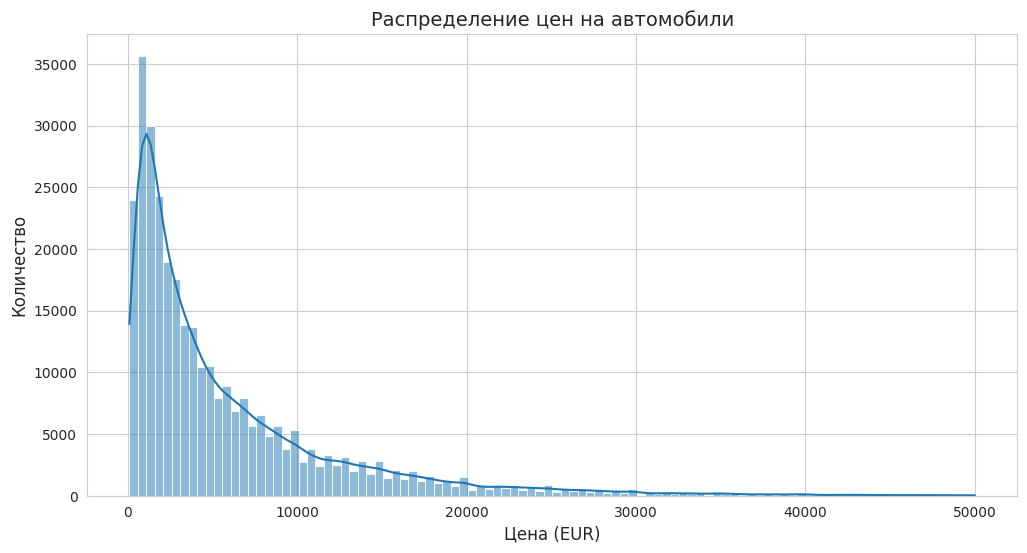

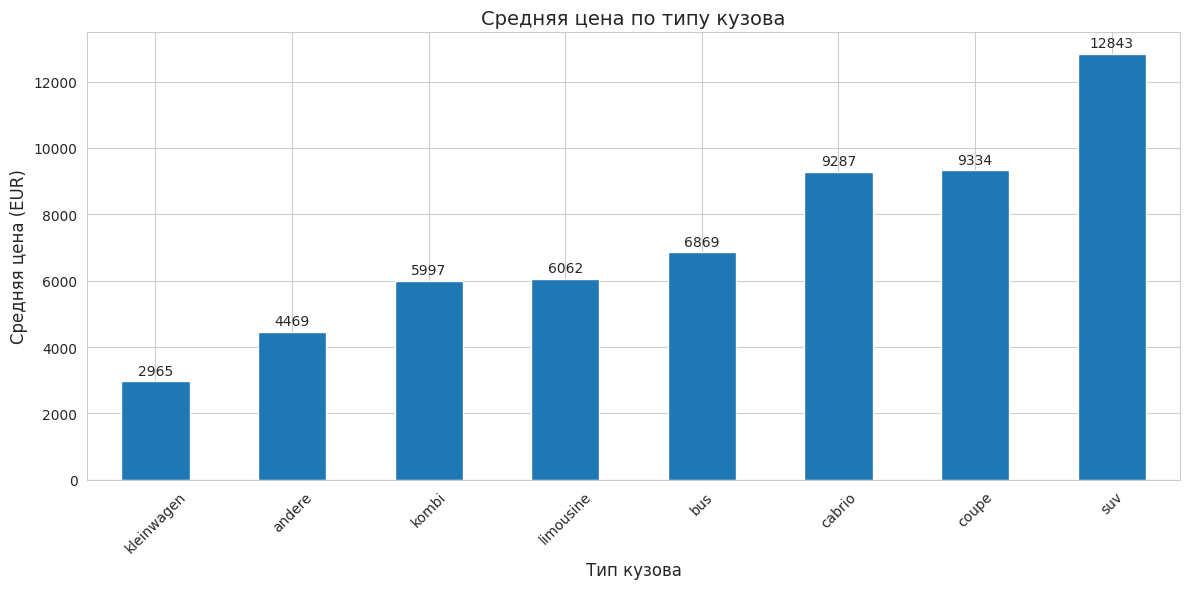

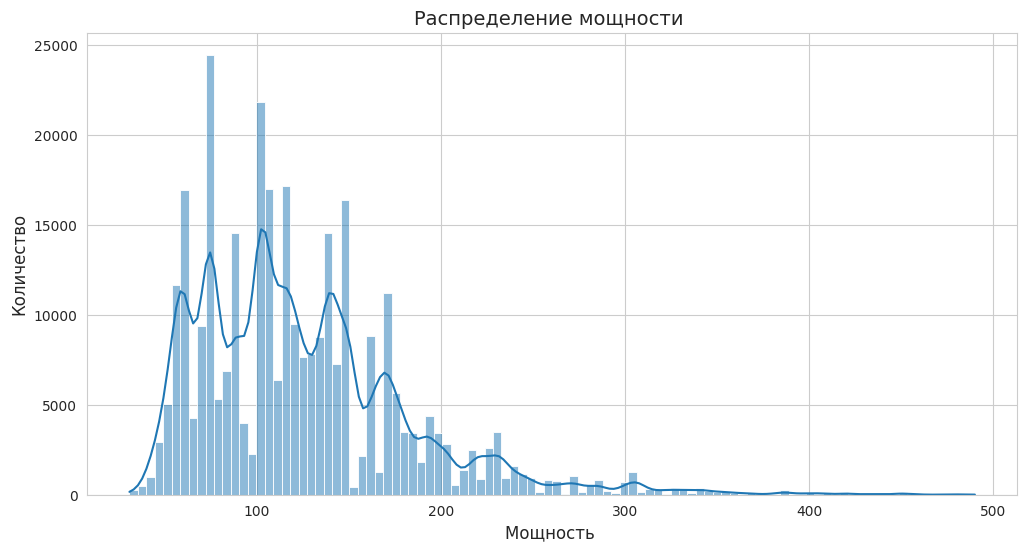

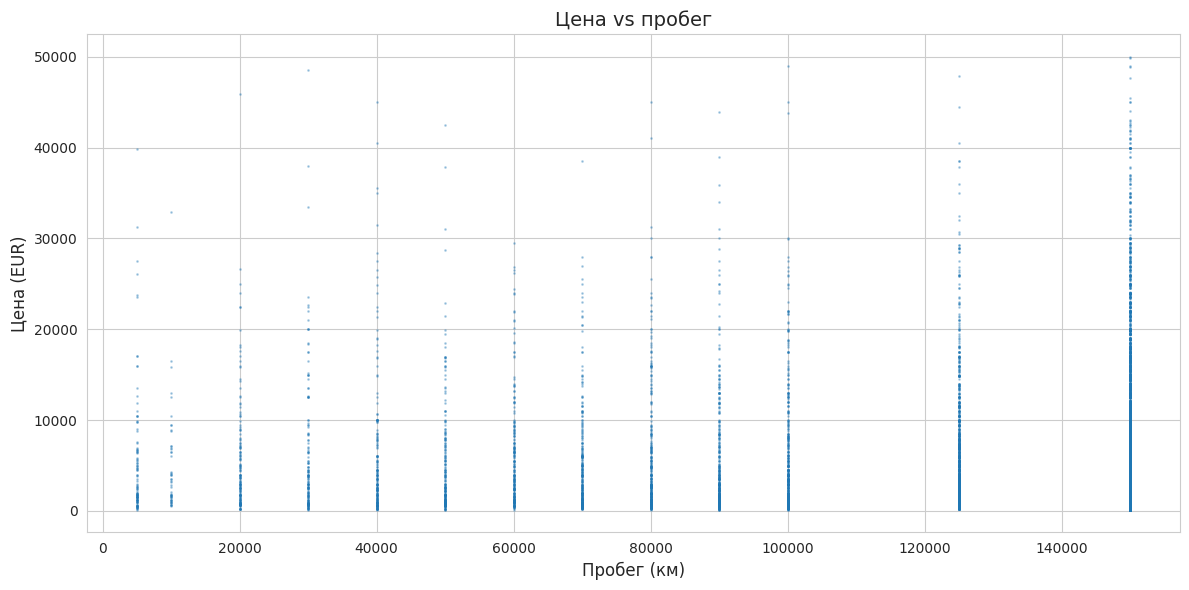

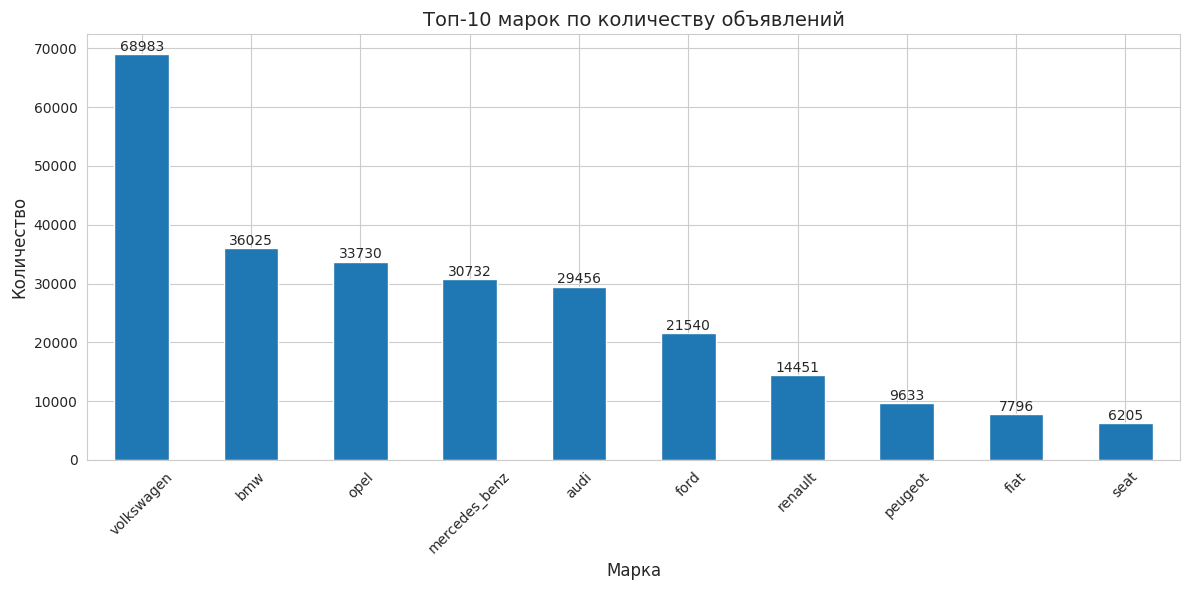

In [19]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

# Настройка стиля графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Загрузка данных частями
file_path = "autos.csv"
chunksize = 10**6  # 1 миллион строк за раз
chunks = []

# Чтение данных с указанием типов для избежания ошибок
for chunk in pd.read_csv(file_path, chunksize=chunksize, encoding='utf-8',
                         low_memory=False, on_bad_lines='skip'):
    chunks.append(chunk)

df = pd.concat(chunks, axis=0)
print(f"Загружено строк: {len(df)}")

# Предпросмотр данных
print("Первые 5 строк:")
print(df.head())
print("\nИнформация о данных:")
print(df.info())

# Удаление бесполезных полей
if 'nrOfPictures' in df.columns:
    df.drop(columns=['nrOfPictures'], inplace=True)

# Преобразование типов данных
# Преобразуем price в числовой тип, заменяя ошибки на NaN
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Преобразуем powerPS
df['powerPS'] = pd.to_numeric(df['powerPS'], errors='coerce')

# Преобразуем kilometer
df['kilometer'] = pd.to_numeric(df['kilometer'], errors='coerce')

# Преобразуем yearOfRegistration
df['yearOfRegistration'] = pd.to_numeric(df['yearOfRegistration'], errors='coerce')

# Преобразуем monthOfRegistration
df['monthOfRegistration'] = pd.to_numeric(df['monthOfRegistration'], errors='coerce')

# Удаляем строки с критическими пропусками (цена, пробег, год регистрации)
df = df.dropna(subset=['price', 'kilometer', 'yearOfRegistration'])

# Обработка пропусков для notRepairedDamage
# Заменяем пропуски на 'unknown'
df['notRepairedDamage'] = df['notRepairedDamage'].fillna('unknown')

# Если в notRepairedDamage есть другие пропуски, заполняем их самым частым значением
if df['notRepairedDamage'].isnull().sum() > 0:
    imputer = SimpleImputer(strategy='most_frequent')
    df['notRepairedDamage'] = imputer.fit_transform(df[['notRepairedDamage']]).ravel()

# Фильтрация выбросов
df = df[(df['price'] > 100) & (df['price'] < 50000)]
df = df[(df['powerPS'] > 30) & (df['powerPS'] < 500)]
df = df[(df['yearOfRegistration'] > 1950) & (df['yearOfRegistration'] < 2025)]

print(f"\nПосле очистки осталось строк: {len(df)}")

# График 1: Распределение цен
plt.figure(figsize=(12, 6))
ax = sns.histplot(df['price'], bins=100, kde=True)
plt.title('Распределение цен на автомобили', fontsize=14)
plt.xlabel('Цена (EUR)', fontsize=12)
plt.ylabel('Количество', fontsize=12)


# График 2: Средняя цена по типу кузова (если столбец существует)
if 'vehicleType' in df.columns and df['vehicleType'].notna().any():
    plt.figure(figsize=(12, 6))
    avg_price_by_type = df.groupby('vehicleType')['price'].mean().sort_values()
    ax2 = avg_price_by_type.plot(kind='bar')
    plt.title('Средняя цена по типу кузова', fontsize=14)
    plt.xlabel('Тип кузова', fontsize=12)
    plt.ylabel('Средняя цена (EUR)', fontsize=12)
    plt.xticks(rotation=45)

    for i, v in enumerate(avg_price_by_type):
        ax2.text(i, v + 100, f'{v:.0f}', ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.show()

# График 3: Распределение мощности
plt.figure(figsize=(12, 6))
ax3 = sns.histplot(df['powerPS'].dropna(), bins=100, kde=True)
plt.title('Распределение мощности ', fontsize=14)
plt.xlabel('Мощность ', fontsize=12)
plt.ylabel('Количество', fontsize=12)



# График 4: Зависимость цены от пробега
plt.figure(figsize=(12, 6))
sample_size = min(10000, len(df))
plt.scatter(df['kilometer'].sample(sample_size),
           df['price'].sample(sample_size),
           alpha=0.3, s=1)
plt.title('Цена vs пробег', fontsize=14)
plt.xlabel('Пробег (км)', fontsize=12)
plt.ylabel('Цена (EUR)', fontsize=12)
plt.tight_layout()
plt.show()

# График 5: Топ-10 марок по количеству объявлений
if 'brand' in df.columns:
    plt.figure(figsize=(12, 6))
    top_brands = df['brand'].value_counts().head(10)
    ax5 = top_brands.plot(kind='bar')
    plt.title('Топ-10 марок по количеству объявлений', fontsize=14)
    plt.xlabel('Марка', fontsize=12)
    plt.ylabel('Количество', fontsize=12)
    plt.xticks(rotation=45)

    for i, v in enumerate(top_brands):
        ax5.text(i, v + 50, str(v), ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.show()
